# Module 2 — Prédiction des efflorescences algales nuisibles (HAB)

Ce notebook réalise tout le pipeline du module 2 :

1. chargement et vérification du dataset ;
2. suppression des doublons ;
3. analyse du déséquilibre des classes ;
4. exclusion de `Bloom_Index` du modèle final pour limiter la fuite d'information ;
5. entraînement d'un réseau neuronal MLP ;
6. comparaison avec XGBoost ;
7. évaluation avec Accuracy, Balanced Accuracy, Precision, Recall, F1-score et ROC-AUC ;
8. sauvegarde des modèles et des résultats.

> Le dataset est synthétique. Les performances obtenues représentent donc une preuve de concept et non une validation sur des mesures environnementales réelles.

In [1]:
from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

cwd = Path.cwd()
if (cwd / 'data').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'data').exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Impossible de trouver le dossier data.")

MODULE2_DIR = PROJECT_ROOT / 'data' / 'module2'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'module2'
MODELS_DIR = PROJECT_ROOT / 'models' / 'module2'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

candidate_files = sorted(MODULE2_DIR.glob('HAB_Artificial_GAN_Dataset*.csv'))
if not candidate_files:
    candidate_files = sorted(MODULE2_DIR.glob('*.csv'))

assert candidate_files, f'Aucun CSV trouvé dans {MODULE2_DIR}'
DATA_FILE = candidate_files[0]

print('Racine du projet :', PROJECT_ROOT)
print('Fichier utilisé :', DATA_FILE)
print('TensorFlow :', tf.__version__)

Racine du projet : C:\Users\elasr\OneDrive\Desktop\hind
Fichier utilisé : C:\Users\elasr\OneDrive\Desktop\hind\data\module2\HAB_Artificial_GAN_Dataset.csv
TensorFlow : 2.21.0


## 1. Chargement et contrôle des données

In [2]:
df_raw = pd.read_csv(DATA_FILE)

expected_columns = [
    'Bloom_Index',
    'Rolling_Chlorophyll_Anomaly',
    'Rolling_SST_Anomaly',
    'Surface_Chlorophyll',
    'Sea_Surface_Temperature',
    'Dissolved_Oxygen',
    'pH',
    'Total_Nitrogen',
    'Total_Phosphorus',
    'HAB_Present'
]

missing_columns = [col for col in expected_columns if col not in df_raw.columns]
assert not missing_columns, f'Colonnes manquantes : {missing_columns}'

print('Dimensions initiales :', df_raw.shape)
print('Valeurs manquantes :', int(df_raw.isna().sum().sum()))
print('Lignes dupliquées :', int(df_raw.duplicated().sum()))
print('\nRépartition initiale de la cible :')
display(df_raw['HAB_Present'].value_counts().rename_axis('classe').to_frame('nombre'))

df_raw.head()

Dimensions initiales : (2000, 10)
Valeurs manquantes : 0
Lignes dupliquées : 65

Répartition initiale de la cible :


,nombre
classe,
0,1667
1,333


,Bloom_Index,Rolling_Chlorophyll_Anomaly,Rolling_SST_Anomaly,Surface_Chlorophyll,Sea_Surface_Temperature,Dissolved_Oxygen,pH,Total_Nitrogen,Total_Phosphorus,HAB_Present
0,0.866108,2.116924,-1.235337,10.000000,28.145262,0.000000,9.500000,3.993261,0.549777,1
1,-0.286023,0.402557,0.583547,6.876402,23.574715,3.480887,8.838746,1.651405,0.813351,0
2,-0.233059,1.891534,-2.193142,10.000000,20.691051,2.963429,9.363664,3.595234,0.666357,0
3,-0.339769,1.462930,-0.522037,9.254859,27.028420,1.913296,7.786122,3.601758,0.625197,0
4,0.689511,3.126583,-1.352139,4.343017,21.867188,0.000000,8.986235,2.608241,0.258732,1


## 2. Nettoyage

Les doublons sont supprimés avant la séparation train/test afin d'éviter qu'une observation identique apparaisse dans les deux ensembles.

In [3]:
df = df_raw.drop_duplicates().reset_index(drop=True).copy()

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna().reset_index(drop=True)
df['HAB_Present'] = df['HAB_Present'].astype(int)

assert set(df['HAB_Present'].unique()) == {0, 1}
assert np.isfinite(df.to_numpy(dtype=float)).all()

clean_path = PROCESSED_DIR / 'module2_hab_clean.csv'
df.to_csv(clean_path, index=False, encoding='utf-8-sig')

print('Dimensions après nettoyage :', df.shape)
print('Doublons supprimés :', len(df_raw) - len(df))
print('Dataset propre sauvegardé dans :', clean_path)

class_counts = df['HAB_Present'].value_counts().sort_index()
class_percentages = (class_counts / len(df) * 100).round(2)
display(pd.DataFrame({'nombre': class_counts, 'pourcentage': class_percentages}))

Dimensions après nettoyage : (1935, 10)
Doublons supprimés : 65
Dataset propre sauvegardé dans : C:\Users\elasr\OneDrive\Desktop\hind\data\processed\module2_hab_clean.csv


,nombre,pourcentage
HAB_Present,,
0,1667,86.15
1,268,13.85


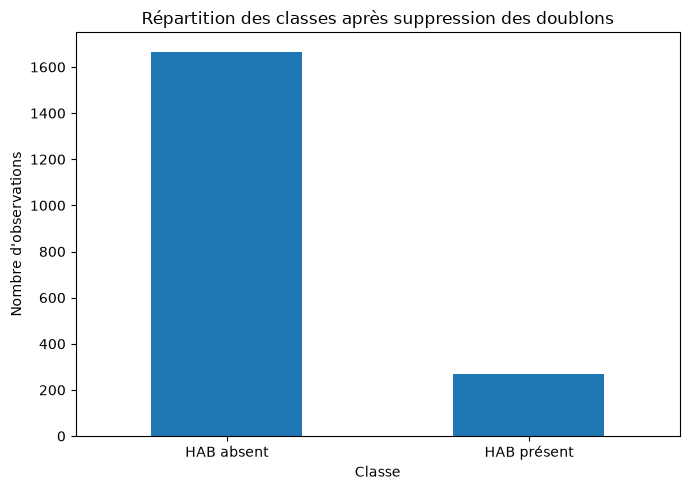

In [4]:
plt.figure(figsize=(7, 5))
class_counts.rename(index={0: 'HAB absent', 1: 'HAB présent'}).plot(kind='bar')
plt.title('Répartition des classes après suppression des doublons')
plt.xlabel('Classe')
plt.ylabel("Nombre d'observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'repartition_classes.png', dpi=160, bbox_inches='tight')
plt.show()

## 3. Analyse des corrélations

`Bloom_Index` est conservé dans le dataset propre, mais exclu des modèles finaux car il est très proche de la définition même d'une efflorescence. Son utilisation pourrait rendre l'évaluation artificiellement trop facile.

Corrélations avec HAB_Present :


,correlation
Bloom_Index,0.791722
Dissolved_Oxygen,-0.532166
Total_Phosphorus,-0.492361
Rolling_Chlorophyll_Anomaly,0.359146
Surface_Chlorophyll,-0.303318
pH,0.254084
Sea_Surface_Temperature,0.220576
Rolling_SST_Anomaly,-0.105104
Total_Nitrogen,-0.024464


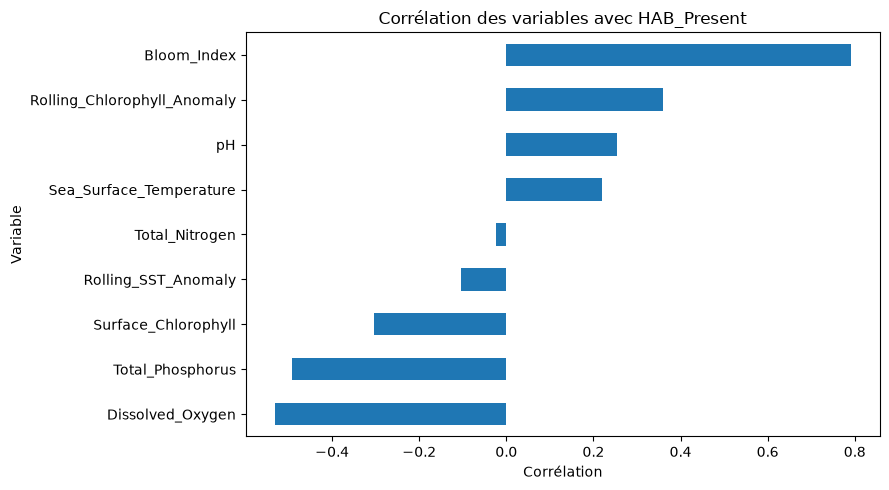

In [5]:
target_correlations = (
    df.corr(numeric_only=True)['HAB_Present']
    .drop('HAB_Present')
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print('Corrélations avec HAB_Present :')
display(target_correlations.to_frame('correlation'))

plt.figure(figsize=(9, 5))
target_correlations.sort_values().plot(kind='barh')
plt.title('Corrélation des variables avec HAB_Present')
plt.xlabel('Corrélation')
plt.ylabel('Variable')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'correlations_cible.png', dpi=160, bbox_inches='tight')
plt.show()

## 4. Préparation des ensembles train, validation et test

Le modèle final utilise toutes les variables environnementales sauf `Bloom_Index`.

In [6]:
TARGET = 'HAB_Present'
EXCLUDED_FEATURES = ['Bloom_Index']
FEATURES = [
    col for col in df.columns
    if col not in [TARGET] + EXCLUDED_FEATURES
]

X = df[FEATURES].to_numpy(dtype=np.float32)
y = df[TARGET].to_numpy(dtype=np.int32)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.1764705882,
    stratify=y_train_full,
    random_state=SEED
)

print('Variables utilisées :', FEATURES)
print('Variables exclues :', EXCLUDED_FEATURES)
print('Train :', X_train.shape, np.bincount(y_train))
print('Validation :', X_val.shape, np.bincount(y_val))
print('Test :', X_test.shape, np.bincount(y_test))

Variables utilisées : ['Rolling_Chlorophyll_Anomaly', 'Rolling_SST_Anomaly', 'Surface_Chlorophyll', 'Sea_Surface_Temperature', 'Dissolved_Oxygen', 'pH', 'Total_Nitrogen', 'Total_Phosphorus']
Variables exclues : ['Bloom_Index']
Train : (1353, 8) [1165  188]
Validation : (291, 8) [251  40]
Test : (291, 8) [251  40]


## 5. Réseau neuronal MLP

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight='balanced', classes=classes, y=y_train
)
class_weight = {0: float(weights[0]), 1: float(weights[1])}

print('Poids des classes :', class_weight)

def build_mlp(n_features: int) -> tf.keras.Model:
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.25),
        Dense(32, activation='relu'),
        Dropout(0.20),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='accuracy'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )
    return model

mlp_model = build_mlp(X_train_scaled.shape[1])
mlp_model.summary()

Poids des classes : {0: 0.58068669527897, 1: 3.598404255319149}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 128 (512.00 B)

In [8]:
history = mlp_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[
        EarlyStopping(
            monitor='val_auc', mode='max', patience=10,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=5,
            min_lr=1e-6, verbose=1
        )
    ],
    verbose=1
)

mlp_probabilities = mlp_model.predict(X_test_scaled, verbose=0).ravel()
mlp_predictions = (mlp_probabilities >= 0.5).astype(int)

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.6098 - auc: 0.9165 - loss: 0.4801 - precision: 0.2585 - recall: 0.9681 - val_accuracy: 0.9656 - val_auc: 0.9790 - val_loss: 0.5123 - val_precision: 0.9167 - val_recall: 0.8250 - learning_rate: 0.0010
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9305 - auc: 0.9844 - loss: 0.2142 - precision: 0.6715 - recall: 0.9787 - val_accuracy: 0.9828 - val_auc: 0.9922 - val_loss: 0.3046 - val_precision: 0.9487 - val_recall: 0.9250 - learning_rate: 0.0010
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9564 - auc: 0.9917 - loss: 0.1314 - precision: 0.7722 - recall: 0.9734 - val_accuracy: 0.9828 - val_auc: 0.9929 - val_loss: 0.1770 - val_precision: 0.9487 - val_recall: 0.9250 - learning_rate: 0.0010
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9778 - auc: 0.9971 - loss: 0.0778 - precision: 0.8726 - recall: 0.9840 - val_accuracy: 0.9794 - val_auc: 0.9918 - val_loss: 0.1072 - val_pr

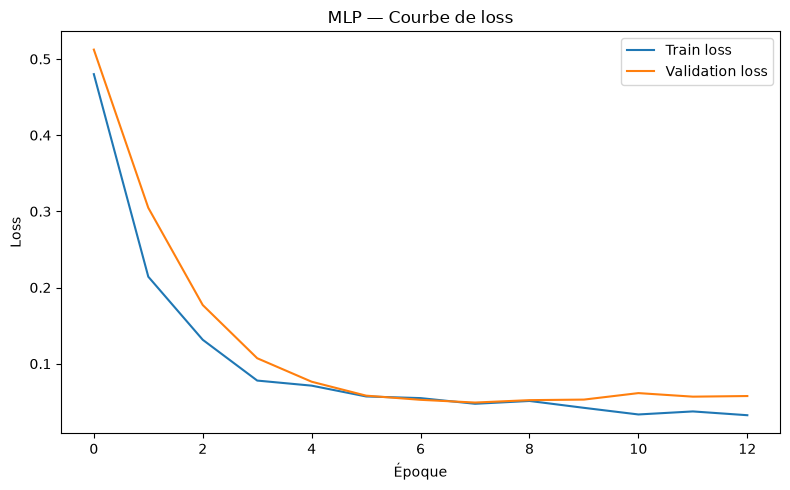

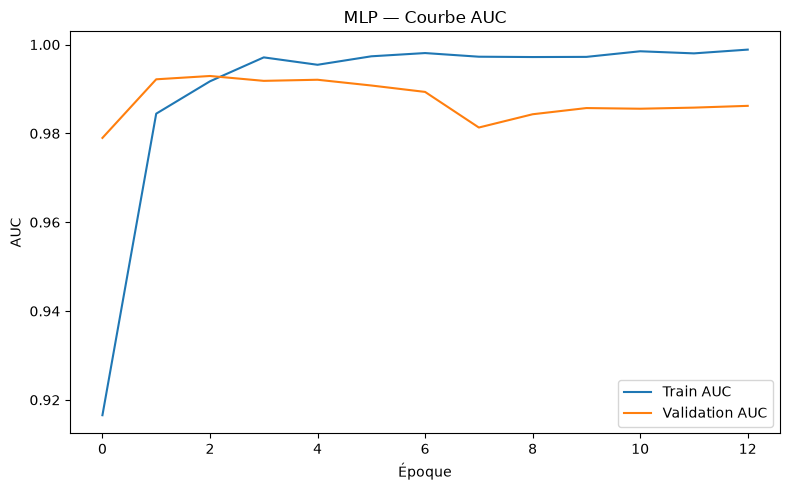

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('MLP — Courbe de loss')
plt.xlabel('Époque')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'mlp_loss.png', dpi=160, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('MLP — Courbe AUC')
plt.xlabel('Époque')
plt.ylabel('AUC')
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'mlp_auc.png', dpi=160, bbox_inches='tight')
plt.show()

## 6. Modèle comparatif XGBoost

In [10]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.01,
    reg_lambda=1.0,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=SEED,
    n_jobs=4
)

xgb_sample_weights = compute_sample_weight(
    class_weight='balanced', y=y_train_full
)

xgb_model.fit(
    X_train_full, y_train_full,
    sample_weight=xgb_sample_weights
)

xgb_probabilities = xgb_model.predict_proba(X_test)[:, 1]
xgb_predictions = (xgb_probabilities >= 0.5).astype(int)

## 7. Comparaison des modèles

In [11]:
def calculate_metrics(name, y_true, predictions, probabilities):
    return {
        'model': name,
        'accuracy': accuracy_score(y_true, predictions),
        'balanced_accuracy': balanced_accuracy_score(y_true, predictions),
        'precision': precision_score(y_true, predictions, zero_division=0),
        'recall': recall_score(y_true, predictions, zero_division=0),
        'f1': f1_score(y_true, predictions, zero_division=0),
        'roc_auc': roc_auc_score(y_true, probabilities)
    }

metrics_df = pd.DataFrame([
    calculate_metrics('MLP', y_test, mlp_predictions, mlp_probabilities),
    calculate_metrics('XGBoost', y_test, xgb_predictions, xgb_probabilities)
])

display(metrics_df)

print('Rapport MLP :')
print(classification_report(
    y_test, mlp_predictions,
    target_names=['HAB absent', 'HAB présent'],
    digits=4, zero_division=0
))

print('Rapport XGBoost :')
print(classification_report(
    y_test, xgb_predictions,
    target_names=['HAB absent', 'HAB présent'],
    digits=4, zero_division=0
))

metrics_df.to_csv(
    RESULTS_DIR / 'comparaison_modeles.csv',
    index=False,
    encoding='utf-8-sig'
)

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,MLP,0.989691,0.983516,0.95122,0.975,0.962963,0.999801
1,XGBoost,0.996564,0.998008,0.97561,1.000,0.987654,1.000000


Rapport MLP :
              precision    recall  f1-score   support

  HAB absent     0.9960    0.9920    0.9940       251
 HAB présent     0.9512    0.9750    0.9630        40

    accuracy                         0.9897       291
   macro avg     0.9736    0.9835    0.9785       291
weighted avg     0.9898    0.9897    0.9897       291

Rapport XGBoost :
              precision    recall  f1-score   support

  HAB absent     1.0000    0.9960    0.9980       251
 HAB présent     0.9756    1.0000    0.9877        40

    accuracy                         0.9966       291
   macro avg     0.9878    0.9980    0.9928       291
weighted avg     0.9966    0.9966    0.9966       291



<Figure size 600x500 with 0 Axes>

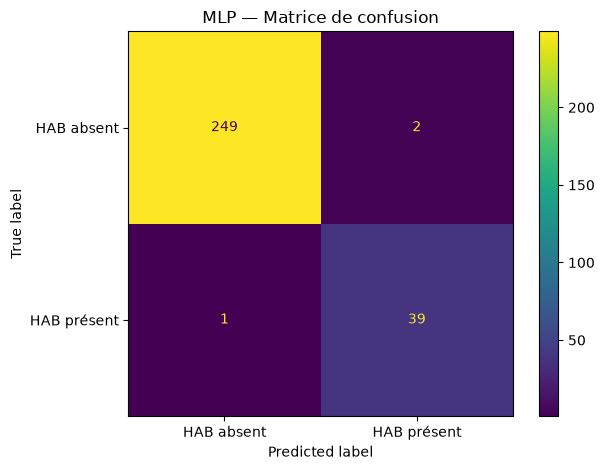

<Figure size 600x500 with 0 Axes>

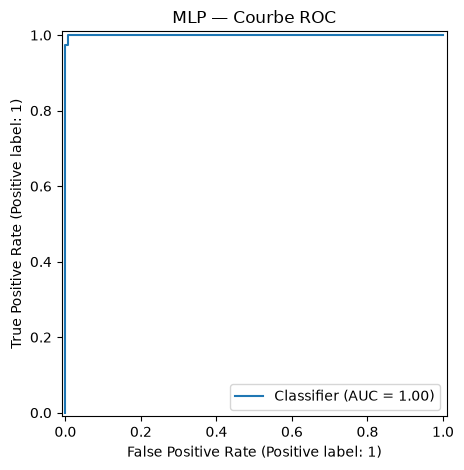

<Figure size 600x500 with 0 Axes>

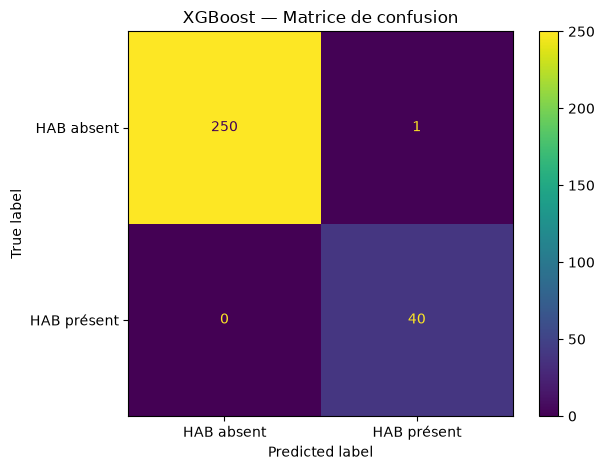

<Figure size 600x500 with 0 Axes>

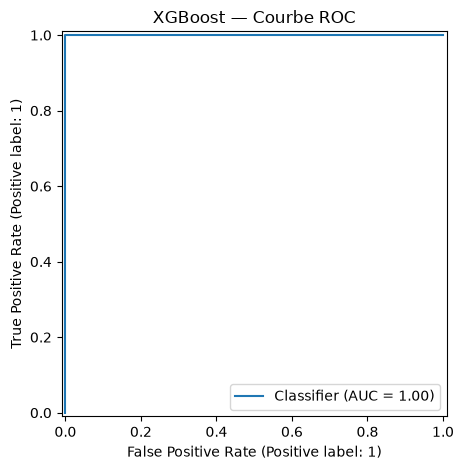

In [12]:
for name, predictions, probabilities in [
    ('MLP', mlp_predictions, mlp_probabilities),
    ('XGBoost', xgb_predictions, xgb_probabilities)
]:
    safe_name = name.lower()

    plt.figure(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test, predictions,
        display_labels=['HAB absent', 'HAB présent'],
        values_format='d'
    )
    plt.title(f'{name} — Matrice de confusion')
    plt.tight_layout()
    plt.savefig(
        RESULTS_DIR / f'{safe_name}_confusion_matrix.png',
        dpi=160, bbox_inches='tight'
    )
    plt.show()

    plt.figure(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y_test, probabilities)
    plt.title(f'{name} — Courbe ROC')
    plt.tight_layout()
    plt.savefig(
        RESULTS_DIR / f'{safe_name}_roc.png',
        dpi=160, bbox_inches='tight'
    )
    plt.show()

## 8. Importance des variables selon XGBoost

,feature,importance
4,Dissolved_Oxygen,0.537823
7,Total_Phosphorus,0.144049
0,Rolling_Chlorophyll_Anomaly,0.097316
5,pH,0.064001
3,Sea_Surface_Temperature,0.050070
6,Total_Nitrogen,0.036418
2,Surface_Chlorophyll,0.036071
1,Rolling_SST_Anomaly,0.034252


<Figure size 900x500 with 0 Axes>

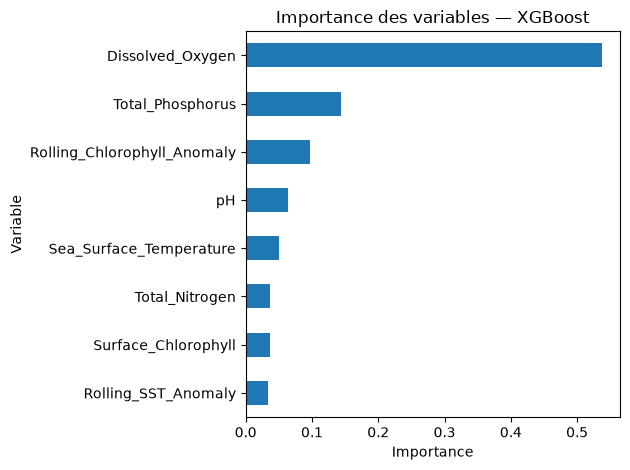

In [13]:
importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

display(importance_df)

plt.figure(figsize=(9, 5))
importance_df.sort_values('importance').plot(
    x='feature', y='importance', kind='barh', legend=False
)
plt.title('Importance des variables — XGBoost')
plt.xlabel('Importance')
plt.ylabel('Variable')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'importance_variables.png', dpi=160, bbox_inches='tight')
plt.show()

importance_df.to_csv(
    RESULTS_DIR / 'importance_variables.csv',
    index=False,
    encoding='utf-8-sig'
)

## 9. Sauvegarde des modèles finaux

Le MLP est conservé comme modèle Deep Learning principal du module 2. XGBoost est sauvegardé comme modèle comparatif.

In [14]:
mlp_path = MODELS_DIR / 'module2_mlp_final.keras'
scaler_path = MODELS_DIR / 'module2_scaler.joblib'
xgb_path = MODELS_DIR / 'module2_xgboost_comparison.joblib'
metadata_path = MODELS_DIR / 'module2_metadata.json'

mlp_model.save(mlp_path)
joblib.dump(scaler, scaler_path)
joblib.dump(xgb_model, xgb_path)

metadata = {
    'task': 'HAB_binary_prediction',
    'main_model': 'MLP',
    'comparison_model': 'XGBoost',
    'target': TARGET,
    'features': FEATURES,
    'excluded_features': EXCLUDED_FEATURES,
    'threshold': 0.5,
    'class_0': 'HAB absent',
    'class_1': 'HAB present',
    'dataset_type': 'synthetic GAN-generated dataset',
    'limitations': [
        'Synthetic data do not replace field validation.',
        'Bloom_Index was excluded to reduce target leakage.',
        'The positive class is less frequent than the negative class.'
    ]
}

metadata_path.write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2),
    encoding='utf-8'
)

predictions_df = pd.DataFrame({
    'true_label': y_test,
    'mlp_probability': mlp_probabilities,
    'mlp_prediction': mlp_predictions,
    'xgboost_probability': xgb_probabilities,
    'xgboost_prediction': xgb_predictions
})
predictions_df.to_csv(
    RESULTS_DIR / 'test_predictions.csv',
    index=False,
    encoding='utf-8-sig'
)

print('✅ MLP :', mlp_path)
print('✅ Scaler :', scaler_path)
print('✅ XGBoost comparatif :', xgb_path)
print('✅ Métadonnées :', metadata_path)
print('✅ Résultats :', RESULTS_DIR)

✅ MLP : C:\Users\elasr\OneDrive\Desktop\hind\models\module2\module2_mlp_final.keras
✅ Scaler : C:\Users\elasr\OneDrive\Desktop\hind\models\module2\module2_scaler.joblib
✅ XGBoost comparatif : C:\Users\elasr\OneDrive\Desktop\hind\models\module2\module2_xgboost_comparison.joblib
✅ Métadonnées : C:\Users\elasr\OneDrive\Desktop\hind\models\module2\module2_metadata.json
✅ Résultats : C:\Users\elasr\OneDrive\Desktop\hind\results\module2


## Fichiers attendus

Dans `models/module2/` :

- `module2_mlp_final.keras`
- `module2_scaler.joblib`
- `module2_xgboost_comparison.joblib`
- `module2_metadata.json`

Dans `results/module2/` :

- `comparaison_modeles.csv`
- matrices de confusion ;
- courbes ROC ;
- courbes d'apprentissage du MLP ;
- importance des variables ;
- prédictions du jeu de test.
